# Bug and Corrections notebook 

## Imports 

In [13]:
import pandas as pd
import logging
import sys
import numpy as np
from dataclasses import asdict
from pathlib import Path

sys.path.append(r"C:\Users\giuli\Repositories\intraday-momentum\src")
path = "/home/corwyn/Black_swan/Intraday_project/intraday-momentum"
sys.path.append("/home/corwyn/Black_swan/Intraday_project/intraday-momentum/src")
from classes.metrics.metrics import MetricsCalculator
from classes.backtest.engine import BacktestEngine  
from classes.backtest.default import BacktestDefaults 

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    force=True,   # <-- allow printing in jupyter notebooks
)

logger = logging.getLogger(__name__)


In [14]:
root = path

df_spy = pd.read_pickle(root + "/data/cleaned/intraday_sp500.pkl")
df_dividends = pd.read_csv(root + "/data/cleaned/SPY_dividends_2022-05-09_2024-04-22.csv")
df_spy_daily = pd.read_pickle(root + "/data/cleaned/daily_sp500.pkl")

# Print information about the dataframes
df_spy.info()
print("\n")
df_dividends.info()
print("\n")
df_spy_daily.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 36754 entries, 2023-12-06 14:30:00+00:00 to 2024-04-22 20:00:00+00:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   volume  36754 non-null  float64
 1   open    36754 non-null  float64
 2   high    36754 non-null  float64
 3   low     36754 non-null  float64
 4   close   36754 non-null  float64
dtypes: float64(5)
memory usage: 1.7 MB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cash_amount       8 non-null      float64
 1   currency          8 non-null      object 
 2   declaration_date  8 non-null      object 
 3   dividend_type     8 non-null      object 
 4   ex_dividend_date  8 non-null      object 
 5   frequency         8 non-null      int64  
 6   id                8 non-null      object 
 7   pay_date       

In [15]:
dfs = {
    "df_spy": df_spy,
    "df_spy_daily": df_spy_daily,
}

for name, df in dfs.items():
    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError(f"{name}: index must be a DatetimeIndex.")
    else:
        logger.info(f"{name}: index is a valid DatetimeIndex with timezone={df.index.tz}.")


2025-12-10 23:44:56,580 | INFO | df_spy: index is a valid DatetimeIndex with timezone=UTC.
2025-12-10 23:44:56,581 | INFO | df_spy_daily: index is a valid DatetimeIndex with timezone=UTC.
2025-12-10 23:44:56,581 | INFO | df_spy_daily: index is a valid DatetimeIndex with timezone=UTC.


### Dividends

In [16]:
# Make a copy
df_dividends_prepared = df_dividends.copy()

# Rename columns to match what MetricsCalculator expects
df_dividends_prepared = df_dividends_prepared.rename(columns={
    "ex_dividend_date": "caldt",  # Metrics expects 'caldt'
    "cash_amount": "dividend"     # Metrics expects 'dividend'
})

# Convert 'caldt' to datetime
df_dividends_prepared["caldt"] = pd.to_datetime(df_dividends_prepared["caldt"])

# Keep only the necessary columns
df_dividends_prepared = df_dividends_prepared[["caldt", "dividend", "ticker"]]

# Verify
print(df_dividends_prepared.head())
print(df_dividends_prepared.columns)

       caldt  dividend ticker
0 2023-12-15  1.906073    SPY
1 2023-09-15  1.583169    SPY
2 2023-06-16  1.638367    SPY
3 2023-03-17  1.506204    SPY
4 2024-12-20  1.965548    SPY
Index(['caldt', 'dividend', 'ticker'], dtype='object')


### Metrics

In [17]:
mc = MetricsCalculator()
df_spy, df_spy_daily = mc.from_clean_df(df_spy, df_dividends_prepared)
mc.quality_check(df_spy, df_spy_daily)
mc.logger.info("All SPY metrics successfully computed.")

2025-12-10 23:44:56,641 | INFO | Starting computation of market microstructure metrics...


2025-12-10 23:44:57,177 | INFO | Running quality checks...
2025-12-10 23:44:57,180 | INFO | NaN summary:
log_returns    1
RV             0
BV             0
vwap           0
price          0
day            0
dtype: int64
2025-12-10 23:44:57,181 | INFO | df_all_days shape: (36754, 21)
2025-12-10 23:44:57,182 | INFO | df_daily_profiles shape: (36754, 22)
2025-12-10 23:44:57,180 | INFO | NaN summary:
log_returns    1
RV             0
BV             0
vwap           0
price          0
day            0
dtype: int64
2025-12-10 23:44:57,181 | INFO | df_all_days shape: (36754, 21)
2025-12-10 23:44:57,182 | INFO | df_daily_profiles shape: (36754, 22)
2025-12-10 23:44:57,229 | INFO | df_all saved to data/processed/df_all_days.pkl
2025-12-10 23:44:57,229 | INFO | df_all saved to data/processed/df_all_days.pkl
2025-12-10 23:44:57,272 | INFO | df_daily saved to data/processed/df_daily_groups.pkl
2025-12-10 23:44:57,273 | INFO | Running quality checks...
2025-12-10 23:44:57,278 | INFO | NaN summary:


So 

In [18]:
# Check
print(df_spy.tail())


                      timestamp     volume     open     high      low  \
36749 2024-04-22 19:56:00+00:00   610685.0  499.350  499.530  499.305   
36750 2024-04-22 19:57:00+00:00   469276.0  499.445  499.445  499.160   
36751 2024-04-22 19:58:00+00:00   942709.0  499.250  499.250  498.905   
36752 2024-04-22 19:59:00+00:00  2630731.0  499.020  499.700  499.010   
36753 2024-04-22 20:00:00+00:00   362284.0  499.630  499.730  499.000   

         close         day       price        vwap  log_returns  ...  \
36749  499.450  2024-04-22  499.428333  498.863819     0.000200  ...   
36750  499.245  2024-04-22  499.283333  498.867361    -0.000411  ...   
36751  499.015  2024-04-22  499.056667  498.870519    -0.000461  ...   
36752  499.630  2024-04-22  499.446667  498.896142     0.001232  ...   
36753  499.190  2024-04-22  499.306667  498.898641    -0.000881  ...   

             BV         hlc  move_open  spy_dvol   spy_ret  min_from_open  \
36749  0.000029  499.428333   0.003254  0.007405  0

to check this thing we need to plot by hand the lower bound upper bound and check if they make any sense 

Recall 

$$
\text{UpperBound}_{t,\mathrm{HH:MM}}
= \text{Open}_{t,9:30} \times \left( 1 + \sigma_{t,9:30 - \mathrm{HH:MM}} \right)
$$

$$
\text{LowerBound}_{t,\mathrm{HH:MM}}
= \text{Open}_{t,9:30} \times \left( 1 - \sigma_{t,9:30 - \mathrm{HH:MM}} \right)
$$


In [27]:
import pandas as pd
import numpy as np

# --- Assumptions: df_spy has columns 'timestamp' (tz-aware), 'open', 'close', 'day' optional.
# Convert timestamp to pandas datetime if needed:
df_spy['timestamp'] = pd.to_datetime(df_spy['timestamp'])

# 1) Day identifier and ensure sorted
df_spy = df_spy.sort_values('timestamp').reset_index(drop=True)
df_spy['day'] = df_spy['timestamp'].dt.date


# Step PROPRE et ROBUSTE pour définir open_at_930
open_930_per_day = (
    df_spy.groupby("day")
          .apply(lambda df: df.sort_values("timestamp").iloc[0]["open"])
)

# Affectation sans join (évite l'erreur)
df_spy["open_at_930"] = df_spy["day"].map(open_930_per_day)


# Sanity
print("Open_at_930 NaNs:", df_spy['open_at_930'].isna().sum())

# 3) minute_of_day as minutes since first bar of that day (robust to timezone)
first_ts_per_day = df_spy.groupby('day')['timestamp'].first()
# Map first timestamp to each row
df_spy['first_ts'] = df_spy['day'].map(first_ts_per_day)
df_spy['minute_of_day'] = ((df_spy['timestamp'] - df_spy['first_ts']).dt.total_seconds() // 60).astype(int)

# Sanity: check unique range (should start at 0 and go up to ~389 for a normal day)
print("minute_of_day range per sample day:")
print(df_spy.groupby('day')['minute_of_day'].agg([min, max]).head())

# 4) move definition (absolute relative move from open_at_930 to that minute's close)
df_spy['move'] = (df_spy['close'] / df_spy['open_at_930'] - 1).abs()

# 5) sigma: for each minute_of_day take 14-day mean of move across past days
# We'll pivot by minute_of_day and use rolling over days:
# Create helper: for each day-minute pair we need the move; group by minute_of_day and day to aggregate single value
# If there are multiple entries per minute_of_day (should not), take last close within that minute.
agg = df_spy.groupby(['day','minute_of_day'])['move'].last().reset_index()
agg = agg.sort_values(['minute_of_day','day'])

# Now for each minute_of_day compute rolling mean over days
agg['sigma'] = (agg.groupby('minute_of_day')['move']
                  .rolling(window=14, min_periods=14)
                  .mean()
                  .reset_index(level=0, drop=True))

# Join sigma back to main df_spy by day & minute_of_day
agg_key = agg.set_index(['day','minute_of_day'])['sigma']
df_spy['sigma'] = df_spy.set_index(['day','minute_of_day']).index.map(agg_key)
# If mapping above fails due to duplicates, alternative: merge:
# df_spy = df_spy.merge(agg[['day','minute_of_day','sigma']], on=['day','minute_of_day'], how='left')

print("Sigma NaNs total:", df_spy['sigma'].isna().sum())
print("Sigma summary (non-null):")
print(df_spy['sigma'].dropna().describe())

# 6) compute gap-adjusted references as in paper
# get previous day's close (we want Close_{t-1,16:00} per day)
# We assume the last timestamp of each day is the close; compute per-day last close and shift
last_close_per_day = df_spy.groupby('day')['close'].last().rename('last_close')
# make a series indexed by day (sorted) then map previous
last_close_df = last_close_per_day.reset_index()
last_close_df['prev_close'] = last_close_df['last_close'].shift(1)
prev_close_map = last_close_df.set_index('day')['prev_close']
df_spy['prev_close'] = df_spy['day'].map(prev_close_map)

# open_ref = max(open_at_930, prev_close)
df_spy['open_ref'] = df_spy[['open_at_930','prev_close']].max(axis=1)
df_spy['low_ref']  = df_spy[['open_at_930','prev_close']].min(axis=1)

# 7) compute bands
df_spy['upper_bnd'] = df_spy['open_ref'] * (1 + df_spy['sigma'])
df_spy['lower_bnd'] = df_spy['low_ref']  * (1 - df_spy['sigma'])

# Diagnostics: fraction of rows with NaN bands
print("upper_bnd NaNs:", df_spy['upper_bnd'].isna().sum())
print("lower_bnd NaNs:", df_spy['lower_bnd'].isna().sum())

# 8) Key checks to answer your problem:
# - Are sigma values extremely small (~0)? -> then bands very tight around open_at_930
print("sigma mean, median, max:", df_spy['sigma'].dropna().agg(['mean','median','max']).to_dict())

# - Fraction of opens (open_at_930) that are outside bounds (should be 0 by construction? we check open at each day's first minute vs band at that minute)
# For each day, pick the row minute_of_day == 0 (the open bar), check if open_at_930 is outside [lower_bnd, upper_bnd]
opens = df_spy[df_spy['minute_of_day']==0].copy()
opens['outside'] = ~((opens['open_at_930'] >= opens['lower_bnd']) & (opens['open_at_930'] <= opens['upper_bnd']))
print("Number of days where open_at_930 is outside its own band:", opens['outside'].sum(), "/", len(opens))

# - Fraction of ANY price (close) outside the noise area (useful)
df_spy['outside_noise'] = (df_spy['close'] > df_spy['upper_bnd']) | (df_spy['close'] < df_spy['lower_bnd'])
print("Fraction of rows outside noise area (non-null sigma rows only):",
      df_spy.loc[df_spy['sigma'].notna(),'outside_noise'].mean())

# - If fraction == 0 (or extremely tiny), likely sigma is near zero or minute mapping wrong.
print("If fraction is ~0, print some sample rows for inspection:")
if df_spy.loc[df_spy['sigma'].notna(),'outside_noise'].mean() < 1e-4:
    display(df_spy[['timestamp','day','minute_of_day','open_at_930','close','sigma','upper_bnd','lower_bnd']].head(40))

Open_at_930 NaNs: 0
minute_of_day range per sample day:
            min  max
day                 
2023-12-06    0  390
2023-12-07    0  390
2023-12-08    0  390
2023-12-11    0  390
2023-12-12    0  390
Sigma NaNs total: 5083
Sigma summary (non-null):
count    31671.000000
mean         0.002547
std          0.001020
min          0.000289
25%          0.001897
50%          0.002461
75%          0.003078
max          0.007535
Name: sigma, dtype: float64
upper_bnd NaNs: 5083
lower_bnd NaNs: 5083
sigma mean, median, max: {'mean': 0.002547196556324758, 'median': 0.002461490227803834, 'max': 0.007535175524977796}
Number of days where open_at_930 is outside its own band: 13 / 94
Fraction of rows outside noise area (non-null sigma rows only): 0.3005588708913517
If fraction is ~0, print some sample rows for inspection:


/tmp/ipykernel_54846/2734726372.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: df.sort_values("timestamp").iloc[0]["open"])
/tmp/ipykernel_54846/2734726372.py:34: FutureWarning: The provided callable <built-in function min> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  print(df_spy.groupby('day')['minute_of_day'].agg([min, max]).head())
/tmp/ipykernel_54846/2734726372.py:34: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep

In [28]:
df_spy["sigma"].describe()
df_spy[["open_at_930", "sigma", "upper_bnd", "lower_bnd"]].head(20)


,open_at_930,sigma,upper_bnd,lower_bnd
0,458.81,NaN,NaN,NaN
1,458.81,NaN,NaN,NaN
2,458.81,NaN,NaN,NaN
3,458.81,NaN,NaN,NaN
4,458.81,NaN,NaN,NaN
5,458.81,NaN,NaN,NaN
6,458.81,NaN,NaN,NaN
7,458.81,NaN,NaN,NaN
8,458.81,NaN,NaN,NaN
9,458.81,NaN,NaN,NaN


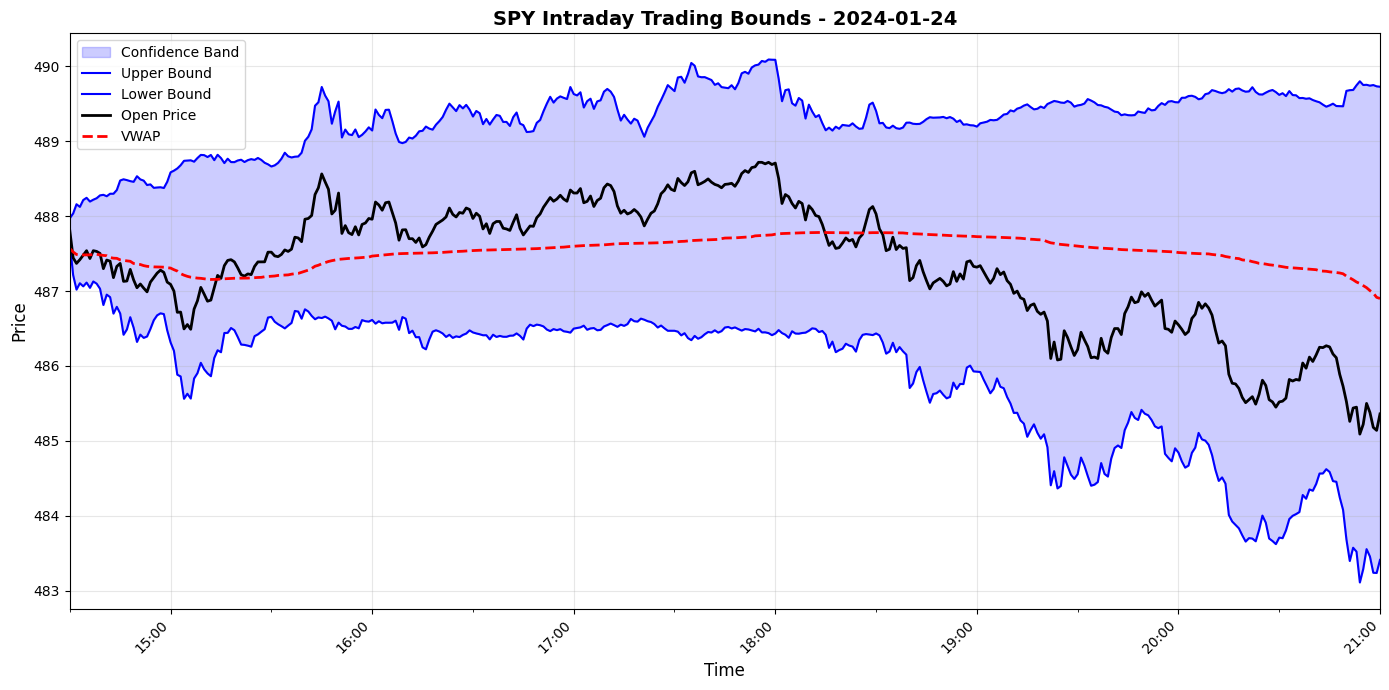

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter
import pandas as pd
import os

# Choose target date (change as needed)
target_date = '2024-01-24'
# Use a proper date object for filtering
target_date_dt = pd.to_datetime(target_date).date()

# Ensure "timestamp" exists and is datetime
if 'timestamp' not in df_spy.columns:
    df_spy['timestamp'] = pd.to_datetime(df_spy.index)
else:
    df_spy['timestamp'] = pd.to_datetime(df_spy['timestamp'])

# Filter by date using .dt.date (robust)
mask = df_spy['timestamp'].dt.date == target_date_dt
df_day = df_spy[mask].copy()

if df_day.empty:
    print(f"No intraday data for {target_date}")
else:
    # Set a clean datetime index without timezone for matplotlib
    df_day.index = df_day['timestamp']
    if getattr(df_day.index, 'tz', None) is not None:
        try:
            df_day.index = df_day.index.tz_convert(None)
        except Exception:
            try:
                df_day.index = df_day.index.tz_localize(None)
            except Exception:
                pass

    # Create plot
    fig, ax = plt.subplots(figsize=(14, 7))

    # Plot the band with transparency
    ax.fill_between(df_day.index, df_day["lower_bnd"], df_day["upper_bnd"], 
                    alpha=0.2, color='blue', label='Confidence Band')

    # Plot upper and lower bounds
    ax.plot(df_day.index, df_day["upper_bnd"], color='blue', linewidth=1.5, label='Upper Bound')
    ax.plot(df_day.index, df_day["lower_bnd"], color='blue', linewidth=1.5, label='Lower Bound')

    # Plot open price
    ax.plot(df_day.index, df_day["open"], color='black', linewidth=2, label='Open Price')

    # Plot VWAP as dashed line if present
    if "vwap" in df_day.columns:
        ax.plot(df_day.index, df_day["vwap"], color='red', linewidth=2, label='VWAP', linestyle='--')

    # Create explicit major (hourly) and minor (30min) ticks using pandas date_range
    start = df_day.index[0].floor('h')
    end = df_day.index[-1].ceil('h')
    major_ticks = pd.date_range(start=start, end=end, freq='60min')
    minor_ticks = pd.date_range(start=start, end=end, freq='30min')

    ax.set_xticks(major_ticks)
    ax.set_xticks(minor_ticks, minor=True)
    ax.xaxis.set_major_formatter(DateFormatter("%H:%M"))

    # Tight x-limits and formatting
    ax.set_xlim([df_day.index[0], df_day.index[-1]])
    plt.xticks(rotation=45, ha='right')

    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel('Price', fontsize=12)
    ax.set_title(f'SPY Intraday Trading Bounds - {target_date}', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    # Save the figure to outputs/figures
    out_dir = os.path.join(path, 'outputs', 'figures')
    os.makedirs(out_dir, exist_ok=True)
    fname = os.path.join(out_dir, f'spy_bounds_{target_date}.png')
    fig.savefig(fname, dpi=150)
    print(f"Saved plot to {fname}")

    plt.show()


### Backtests

The columns we need are these ones : 

["day", "open", "close", "vwap", "sigma_open", "spy_dvol", "min_from_open","dividends"]

In [39]:

defaults = BacktestDefaults(
    minute_path=path + "/notebooks/data/processed/df_all_days.pkl",
    daily_path= path + "/notebooks/data/processed/df_daily_groups.pkl",
    initial_aum=100_000.0,
    commission_rate=0.0035,
    min_comm_per_order=0.35,
    slippage_bps=0,
    band_mult=1.0,
    trade_freq=30,
    sizing_type="full_notional",
    target_vol=0.02,
    max_leverage=4.0, #Warning should be 2.0 in Quantconnect
)

engine = BacktestEngine()
trade_log_df, daily_pnl_df, equity_curve_df = engine.run_backtest(asdict(defaults))

[WARNING] Daily data at '/home/corwyn/Black_swan/Intraday_project/intraday-momentum/notebooks/data/processed/df_daily_groups.pkl' is missing required columns: 'caldt' and/or 'close'.


2025-12-10 23:20:37,972 | INFO | Trade log saved to /home/corwyn/Black_swan/Intraday_project/intraday-momentum/src/data/processed/trade_log.csv
2025-12-10 23:20:37,973 | INFO | Daily PnL saved to /home/corwyn/Black_swan/Intraday_project/intraday-momentum/src/data/processed/daily_pnl.pkl


In [40]:
from classes.viz.plotter import Plotter
df = pd.read_pickle(path + "/src/data/processed/daily_pnl.pkl")
df.index = pd.to_datetime(df.index)

In [41]:
df

,AUM,ret,gross_pnl,commission,slippage_cost,net_pnl,ret_spy
day,,,,,,,
2023-12-26,99904.8390,-0.000952,-90.7089,4.431,0.0,-95.1399,NaN
2023-12-27,99904.8390,0.000000,0.0000,0.000,0.0,0.0000,NaN
2023-12-28,99904.8390,0.000000,0.0000,0.000,0.0,0.0000,NaN
2023-12-29,99987.3690,0.000826,81.9630,1.470,0.0,80.4930,NaN
2024-01-02,99987.3690,0.000000,0.0000,0.000,0.0,0.0000,NaN
...,...,...,...,...,...,...,...
2024-04-16,102921.0092,0.000000,0.0000,0.000,0.0,0.0000,NaN
2024-04-17,102651.6282,-0.002617,-261.8700,1.421,0.0,-263.2910,NaN
2024-04-18,102651.6282,0.000000,0.0000,0.000,0.0,0.0000,NaN


2025-12-10 23:20:38,019 | INFO | Dataframe correctly initialized
2025-12-10 23:20:38,021 | INFO | Computing comulative AUM for SPY
2025-12-10 23:20:38,234 | ERROR | Failed to save plot to /home/corwyn/Black_swan/Intraday_project/intraday-momentum/ouputs/figures/test_01.jpg: [Errno 2] No such file or directory: '/home/corwyn/Black_swan/Intraday_project/intraday-momentum/ouputs/figures/test_01.jpg'


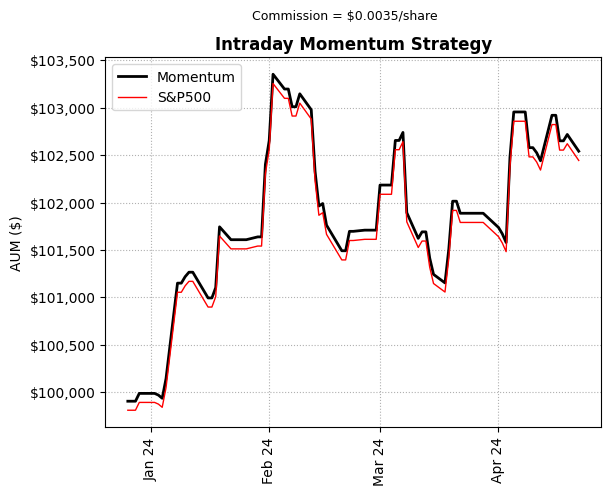

In [42]:

plott = Plotter(df)
# Use actual starting AUM to avoid ValueError
start_aum = df["AUM"].iloc[0]
plott.plot_cum_returns("ret", "AUM",path + "/ouputs/figures/test_01.jpg", AUM_0=start_aum)

In [43]:
plott.compute_statistics("ret", "AUM", 0.000107 )

2025-12-10 23:20:38,339 | INFO | Computing returns and performance statistics such as Sharpe, Hit, Drawdown)


,Total Return (%),Annualized Return (%),Annualized Volatility (%),Sharpe Ratio,Hit Ratio (%),Maximum Drawdown (%)
Value,3.0,8.1,4.5,1.15,49.0,2.0
